# Importing Libraries & Defining Paths


In [1]:
# Defining project paths
BASE_DIR = "D:/Capstone/capstone_repo"
DATA_DIR = f"{BASE_DIR}/data"
RAW_DIR = f"{DATA_DIR}/raw"
PROCESSED_DIR = f"{DATA_DIR}/processed"
DATA_INTERIM = f"{DATA_DIR}/interim"
COLLECTION_OUTPUT_DIR = f"{BASE_DIR}/data/collection_output"

TARGET_CRS = "EPSG:32629"
MAX_ORIGINS = 120_000
AGGREGATION_GRID_M = 200.0

gpkg_path = f"{PROCESSED_DIR}/Casablanca_Districts.gpkg"
raster_path = f"{RAW_DIR}/worldpop_population.tif"
clipped_raster_path = f"{DATA_INTERIM}/worldpop_clipped.tif"
worldpop_origins_gpkg_path = f"{DATA_INTERIM}/worldpop_origins.gpkg"
worldpop_origins_csv_path = f"{DATA_INTERIM}/worldpop_origins.csv"

import os
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(DATA_INTERIM, exist_ok=True)
os.makedirs(COLLECTION_OUTPUT_DIR, exist_ok=True)


In [2]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterstats import zonal_stats
from rasterio.mask import mask
from rasterio.transform import xy

# Loading Data

In [3]:
# Load district polygons
districts = gpd.read_file(gpkg_path)

print("District columns:", districts.columns.tolist())
print("District CRS:", districts.crs)
print("Number of districts:", len(districts))


District columns: ['district', 'commune', 'commune_type_encoded', 'geometry']
District CRS: EPSG:4326
Number of districts: 34


# raster inspection, zonal statistics, and clipping

In [5]:
# zonal statistics, and clipping to reduce redundancy.
with rasterio.open(raster_path) as src:
    # Check that the raster has a defined coordinate reference system
    if src.crs is None:
        raise ValueError("WorldPop raster has no CRS")

    # Print key raster properties for verification
    print("Raster CRS:", src.crs)
    print("Raster bounds:", src.bounds)
    print("Raster resolution:", src.res)
    print("Raster nodata:", src.nodata)

    # Reproject district boundaries to the raster CRS for raster-based operations
    districts_raster = districts.to_crs(src.crs) if districts.crs != src.crs else districts.copy()

    # Compute district-level zonal statistics from the population raster
    stats = zonal_stats(
        districts_raster,
        raster_path,
        stats=["sum", "mean", "max"],
        nodata=src.nodata,
        geojson_out=False
    )

    # Add zonal statistics to the district GeoDataFrame
    districts["population_worldpop"] = [s["sum"] for s in stats]
    districts["pop_mean_pixel"] = [s["mean"] for s in stats]
    districts["pop_max_pixel"] = [s["max"] for s in stats]

    # Replace missing values with zero for consistency
    districts["population_worldpop"] = districts["population_worldpop"].fillna(0)
    districts["pop_mean_pixel"] = districts["pop_mean_pixel"].fillna(0)
    districts["pop_max_pixel"] = districts["pop_max_pixel"].fillna(0)

    # Calculate area in square kilometers and population density
    districts_projected = districts.to_crs(TARGET_CRS)  
    districts["area_km2"] = districts_projected.geometry.area / 1_000_000
    districts["pop_density_km2"] = districts["population_worldpop"] / districts["area_km2"]

    # Convert district geometries to GeoJSON-like objects for raster masking
    geoms = [g.__geo_interface__ for g in districts_raster.geometry]

    # Clip the raster to the district study area
    clipped_arr, clipped_transform = mask(
        src,
        geoms,
        crop=True,
        nodata=src.nodata,
        filled=True
    )

    # Extract the first band and convert it to float32
    clipped_band = clipped_arr[0].astype(np.float32)

    # Save useful raster metadata for later use
    raster_nodata = src.nodata
    raster_crs = src.crs

    # Prepare output metadata for writing the clipped raster
    out_meta = src.meta.copy()
    out_meta.update({
        "height": clipped_band.shape[0],
        "width": clipped_band.shape[1],
        "transform": clipped_transform,
        "count": 1,
        "dtype": "float32",
    })

Raster CRS: EPSG:4326
Raster bounds: BoundingBox(left=-13.167916599, bottom=27.669583424, right=-0.9979166480000004, top=35.922916724)
Raster resolution: (0.0008333333299780882, 0.0008333333299676896)
Raster nodata: -99999.0


# Save Clipped Raster

In [6]:
with rasterio.open(clipped_raster_path, "w", **out_meta) as dst:
    dst.write(clipped_band, 1)

print("Clipped raster saved:", clipped_raster_path)

Clipped raster saved: D:/Capstone/capstone_repo/data/interim/worldpop_clipped.tif


# Extract Valid Population Cells

In [7]:
# Extract valid population data from the clipped raster for origin generation
arr = clipped_band
nodata = raster_nodata
t = clipped_transform
r_crs = raster_crs

# Identify valid raster cells with positive population values
valid = np.isfinite(arr) & (arr > 0)

# Exclude nodata cells when a nodata value is defined
if nodata is not None:
    valid = valid & (arr != nodata)

# Get indices of valid cells
rows, cols = np.where(valid)

# Stop if no populated cells are found
if len(rows) == 0:
    raise ValueError("No valid positive raster cells")

# Extract population values for valid cells
pops = arr[rows, cols].astype(np.float32)

# Compute the center coordinates of valid raster cells
xs, ys = xy(t, rows, cols, offset="center")

## Create population-weighted origin points

In [8]:
# Convert populated raster cells into point-based origins
origins = gpd.GeoDataFrame(
    {
        "origin_id": np.arange(len(pops), dtype=np.int64),
        "population": pops,
    },
    geometry=gpd.points_from_xy(xs, ys),
    crs=r_crs,
).to_crs(TARGET_CRS)

# Store projected coordinates for later distance-based analysis
origins["x"] = origins.geometry.x
origins["y"] = origins.geometry.y

# Reorder columns for clarity
origins = origins[["origin_id", "x", "y", "population", "geometry"]]

print("Number of initial origins:", len(origins))

Number of initial origins: 117107


In [9]:
origins.crs

<Projected CRS: EPSG:32629>
Name: WGS 84 / UTM zone 29N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 12°W and 6°W, northern hemisphere between equator and 84°N, onshore and offshore. Algeria. Côte D'Ivoire (Ivory Coast). Faroe Islands. Guinea. Ireland. Jan Mayen. Liberia, Mali. Mauritania. Morocco. Portugal. Sierra Leone. Spain. United Kingdom (UK). Western Sahara.
- bounds: (-12.01, 0.0, -6.0, 84.01)
Coordinate Operation:
- name: UTM zone 29N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [10]:
# Aggregate origins if too many
if len(origins) > MAX_ORIGINS:
    tmp = origins.copy()

    # Assign grid cells
    tmp["gx"] = np.floor(tmp["x"] / AGGREGATION_GRID_M).astype(np.int32)
    tmp["gy"] = np.floor(tmp["y"] / AGGREGATION_GRID_M).astype(np.int32)

    # Aggregate population and coordinates
    ag = tmp.groupby(["gx", "gy"], as_index=False).agg(
        population=("population", "sum"),
        x=("x", "mean"),
        y=("y", "mean")
    )

    # Convert back to GeoDataFrame
    origins = gpd.GeoDataFrame(
        ag,
        geometry=gpd.points_from_xy(ag["x"], ag["y"]),
        crs=TARGET_CRS
    )

    origins = origins.reset_index(drop=True)
    origins["origin_id"] = np.arange(len(origins), dtype=np.int64)

    origins = origins[["origin_id", "x", "y", "population", "geometry"]]

    print("Origins aggregated to:", len(origins))

In [11]:
# Assign origins to districts
origins = gpd.sjoin(
    origins,
    districts.to_crs(TARGET_CRS),
    how="inner",
    predicate="within"
).drop(columns=["index_right"], errors="ignore")

if origins.empty:
    raise ValueError("No origins assigned to districts")

print("Origins successfully assigned to districts")

Origins successfully assigned to districts


# Save Outputs

In [13]:
# Save origins
origins.to_file(worldpop_origins_gpkg_path, layer="origins", driver="GPKG")
origins.drop(columns="geometry").to_csv(worldpop_origins_csv_path, index=False)

# Save districts
districts_out = districts.to_crs(TARGET_CRS)
districts_out.to_file(f"{PROCESSED_DIR}/districts_with_worldpop.gpkg", driver="GPKG")
districts_out.drop(columns="geometry").to_csv(f"{PROCESSED_DIR}/districts_with_worldpop.csv", index=False)

print("Done. Files saved:")
print(f"- {clipped_raster_path}")
print(f"- {worldpop_origins_gpkg_path}")
print(f"- {worldpop_origins_csv_path}")
print(f"- {PROCESSED_DIR}/districts_with_worldpop.gpkg")
print(f"- {PROCESSED_DIR}/districts_with_worldpop.csv")

Done. Files saved:
- D:/Capstone/capstone_repo/data/interim/worldpop_clipped.tif
- D:/Capstone/capstone_repo/data/interim/worldpop_origins.gpkg
- D:/Capstone/capstone_repo/data/interim/worldpop_origins.csv
- D:/Capstone/capstone_repo/data/processed/districts_with_worldpop.gpkg
- D:/Capstone/capstone_repo/data/processed/districts_with_worldpop.csv


# Visualization

## Plot District Boundaries

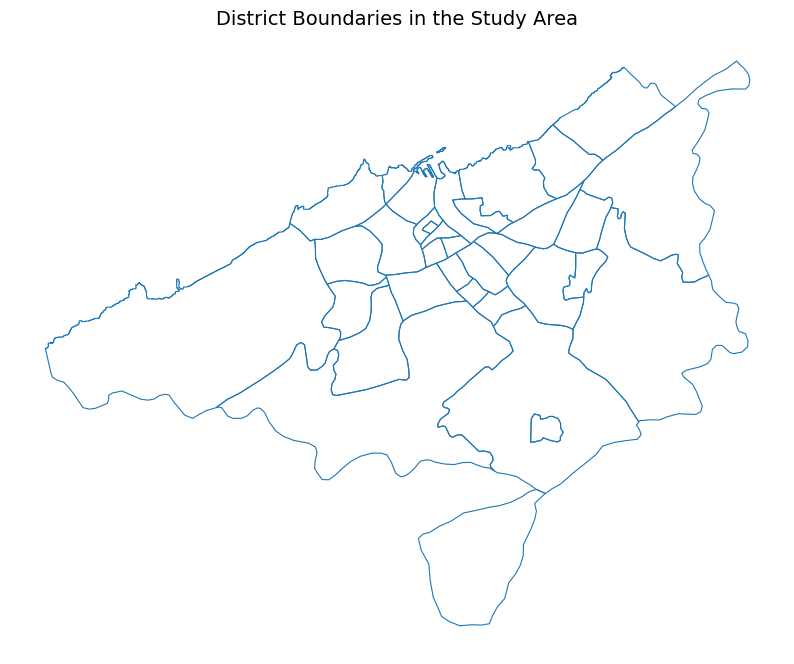

In [16]:
# Reproject districts to the target CRS for consistent plotting
districts_plot = districts.to_crs(TARGET_CRS) if districts_raster.crs != TARGET_CRS else districts_raster.copy()

# Create figure
fig, ax = plt.subplots(figsize=(10, 10))

# Plot district boundaries
districts_plot.boundary.plot(ax=ax, linewidth=0.8)

# Add title
ax.set_title("District Boundaries in the Study Area", fontsize=14)

# Remove axes for cleaner map display
ax.set_axis_off()

plt.show()

## Choropleth of District Population from WorldPop

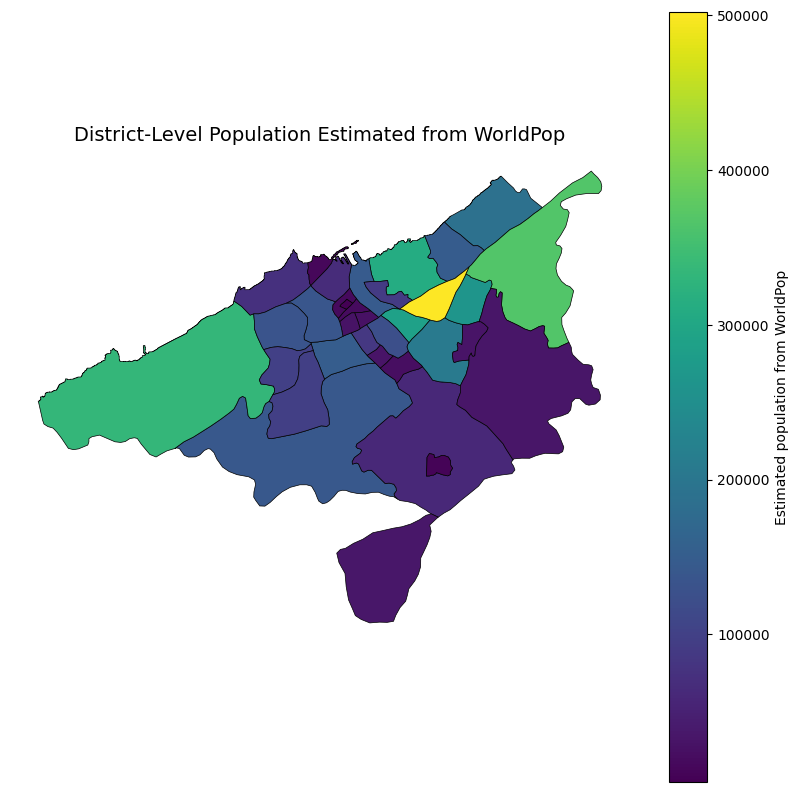

In [17]:
# Create figure
fig, ax = plt.subplots(figsize=(10, 10))

# Plot district population
districts_plot.plot(
    column="population_worldpop",
    ax=ax,
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    legend_kwds={"label": "Estimated population from WorldPop"}
)

# Add title
ax.set_title("District-Level Population Estimated from WorldPop", fontsize=14)

# Remove axes
ax.set_axis_off()

plt.show()